In [1]:
from multivae.data.datasets import MHD


In [2]:
dataset = MHD('/home/asenella/scratch/data/MHD', download=True)

torch.Size([1, 28, 28])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 0])
torch.Size([1, 32, 128])
tensor([0.5557, 0.5567, 0.5585, 0.5596, 0.5601, 0.5607, 0.5619, 0.5624, 0.5620,
        0.5610, 0.5596, 0.5576, 0.5550, 0.5517, 0.5475, 0.5425, 0.5366, 0.5299,
        0.5226, 0.5149, 0.5071, 0.4995, 0.4924, 0.4861, 0.4807, 0.4764, 0.4734,
        0.4716, 0.4712, 0.4723, 0.4752, 0.4798, 0.4863, 0.4948, 0.5050, 0.5169,
        0.5301, 0.5443, 0.5589, 0.5735, 0.5877, 0.6008, 0.6126, 0.6225, 0.6303,
        0.6355, 0.6379, 0.6375, 0.6339, 0.6274, 0.6179, 0.6059, 0.5919, 0.5765,
        0.5607, 0.5452, 0.5307, 0.5179, 0.5069, 0.4977, 0.4902, 0.4842, 0.4793,
        0.4755, 0.4727, 0.4709, 0.4702, 0.4709, 0.4731, 0.4770, 0.4826, 0.4896,
        0.4979, 0.5070, 0.5164, 0.5257, 0.5345, 0.5425, 0.5495, 0.5553, 0.5599,
        0.5630, 0.5647, 0.5649, 0.5635, 0.5607, 0.5566, 0.5516, 0.5461, 0.5402,
        0.5340, 0.5275, 0.5212, 0.5161, 0.5122, 0.5096, 0.5080, 0.5070, 0.5063,
        0.5059, 0.4089, 0.4078, 

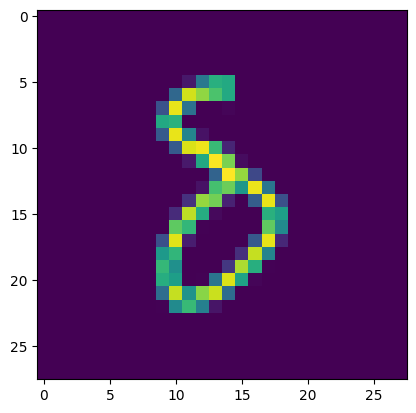

In [3]:
import matplotlib.pyplot as plt
sample = dataset[0]
print(sample.data['image'].shape)
print(sample.data["label"])
plt.imshow(sample.data['image'][0])
print(sample.data['audio'].shape)
print(sample.data['trajectory'])

print(sample.data['image'].max(), sample.data['image'].min())
print(sample.data['audio'].max(), sample.data['audio'].min())
print(sample.data['trajectory'].max(), sample.data['trajectory'].min())

In [29]:
classifiers_path = '../../../data/MHD/classifiers/'
from architectures import *
import os

classifiers = dict(
    image = Image_Classifier(),
    audio = Sound_Classifier(),
    trajectory = Trajectory_Classifier()
    
)

classifiers['audio'].load_state_dict(torch.load(os.path.join(classifiers_path, 'best_sound_classifier_model.pth.tar'), map_location='cpu')['state_dict'])

<All keys matched successfully>

In [32]:
classifiers['audio'].eval()
torch.argmax(classifiers['audio'](sample.data['audio'].unsqueeze(0)))

tensor(7)